# Hoja de trabajo #2 — Transformers y mecanismos de atención

**CC3092 · Deep Learning y Sistemas Inteligentes** — Universidad del Valle de Guatemala

**Nicolás Concuá** · Guatemala, octubre de 2026

Repositorio: https://github.com/nicoCT04/Hoja_trabajo_2_DL

Este notebook recorre el camino **RNN → atención → Transformer**: primero la investigación (secciones 2 a 4), luego
un **ejercicio a mano** de *scaled dot-product attention*, una **implementación desde cero** de atención y multi-head
attention, los experimentos de **escalamiento** (por qué se divide entre √d_k) y de **costo computacional** (O(n²)),
las **verificaciones** contra PyTorch y, por último, el **análisis de atención en BERT y GPT-2**: mapas de calor por
cabeza, correferencia de «it», matriz causal y *attention sinks*, entropía por capa, ablación de cabezas y una prueba
de si la atención explica las predicciones.

## 0. Configuración del entorno

**Hardware:** Apple M4 Pro (backend **MPS** de PyTorch para el experimento de costo; BERT y GPT-2 se corren en CPU,
que para oraciones cortas es suficiente y es determinista). El código usa CUDA automáticamente si existe.

In [1]:
# Descomenta para instalar dependencias (p. ej. en Colab):
# !pip install torch transformers matplotlib pandas numpy bertviz

In [2]:
import os, math, time, random, platform, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from transformers import AutoTokenizer, AutoModel, BertForMaskedLM, GPT2LMHeadModel
transformers.logging.set_verbosity_error()

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.precision', 4)

# Semilla global para reproducibilidad.
SEED = 42
def fijar_semilla(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
fijar_semilla()

# Rutas robustas: funciona si se corre desde la raíz del repo o desde notebook/.
RAIZ = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebook' else os.getcwd()
REPORTS = os.path.join(RAIZ, 'reports')
os.makedirs(REPORTS, exist_ok=True)

# Dispositivo para el benchmark de costo (los modelos preentrenados van en CPU).
if torch.cuda.is_available():
    DEV = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEV = torch.device('mps')
else:
    DEV = torch.device('cpu')

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})

def guardar(fig, nombre):
    """Guarda la figura en reports/ para reutilizarla en el informe."""
    fig.savefig(os.path.join(REPORTS, nombre), bbox_inches='tight')

print('Python', platform.python_version(), '| torch', torch.__version__, '| transformers', transformers.__version__)
print('Dispositivo para el benchmark:', DEV, '|', platform.processor() or platform.machine())

Python 3.12.14 | torch 2.14.1 | transformers 5.18.0
Dispositivo para el benchmark: mps | arm


## 2. Investigación: de las RNN a la atención

**Cuello de botella del seq2seq con RNN.** En el modelo encoder-decoder [4] el encoder lee toda la oración y la
resume en **un solo vector de tamaño fijo** (su último estado oculto), y el decoder genera la traducción solo a partir
de ese vector. La capacidad del vector no crece con la entrada: con oraciones largas hay que comprimir más
información en el mismo espacio y lo del inicio se va «borrando» al pasar por muchos pasos de recurrencia. Cho et al.
mostraron que el BLEU cae fuertemente a partir de ~20 palabras. **Bahdanau** [2] elimina el resumen único: el encoder
(bidireccional) conserva **todos** sus estados h_1…h_T y en cada paso i el decoder calcula un puntaje
e_ij = vᵀ tanh(W s_{i−1} + U h_j) con cada estado, los normaliza con softmax (α_ij) y usa el contexto
c_i = Σ_j α_ij h_j. Cada palabra de salida «mira» directamente las palabras de entrada relevantes (alineamiento
suave), así que la información ya no tiene que sobrevivir a todo el recorrido del encoder.

**Aditiva (Bahdanau) vs. multiplicativa (Luong).** La aditiva compara consulta y llave con una pequeña MLP
(vᵀ tanh(W s + U h)); la multiplicativa [3] usa el producto punto s·h (o sᵀW h, «general»). Ambas tienen complejidad
teórica parecida, pero la de producto punto es **mucho más eficiente en hardware moderno**: todos los puntajes de
una secuencia salen de **una sola multiplicación de matrices** QKᵀ, que las GPU/TPU ejecutan con kernels GEMM
altamente optimizados (tensor cores), mientras que la aditiva necesita materializar un tensor n × m × d_a, aplicar
tanh elemento a elemento y proyectar con v, con más memoria y operaciones menos optimizadas [1]. Su desventaja es que
para d_k grande los productos punto crecen en magnitud — de ahí el escalamiento √d_k del Transformer (sección 3).

**Consulta, llave y valor como diccionario «suave».** Un diccionario normal busca la llave **idéntica** a la
consulta y devuelve **un** valor. La atención compara la consulta con **todas** las llaves (similitud q·k),
convierte las similitudes en pesos que suman 1 (softmax) y devuelve el **promedio ponderado de todos los valores**:
una búsqueda difusa y diferenciable, entrenable por gradiente. En **self-attention** Q, K y V salen de la **misma**
secuencia mediante tres proyecciones aprendidas (Q = XW_Q, K = XW_K, V = XW_V): cada token pregunta a todos los
demás. En **cross-attention** (encoder-decoder) las **consultas vienen del decoder** y las **llaves y valores de la
salida del encoder**: cada token que se genera consulta la oración de origen.

**Qué limitaciones de las RNN elimina el Transformer.**
- *Procesamiento secuencial:* una RNN necesita O(n) pasos que dependen del anterior (h_t requiere h_{t−1}), así que
  no se paraleliza a lo largo de la secuencia. La self-attention procesa todas las posiciones a la vez con
  multiplicaciones de matrices: O(1) operaciones secuenciales por capa [1].
- *Dependencias de largo alcance:* entre dos tokens a distancia k una RNN tiene un camino de longitud O(k); en la
  self-attention cualquier par está conectado **directamente** (camino O(1)).
- *Desvanecimiento del gradiente:* el gradiente en una RNN se multiplica por el Jacobiano de cada paso y tiende a
  desvanecerse o explotar con la distancia [5]; en el Transformer el gradiente entre dos posiciones atraviesa una
  sola atención por capa y las conexiones residuales, sin cadena de n pasos.
- El precio: costo **cuadrático** en n y la pérdida de la noción de orden, que hay que reinyectar con codificación
  posicional.

## 3. Investigación: la arquitectura Transformer

**Scaled dot-product attention.** Attention(Q, K, V) = softmax(QKᵀ / √d_k) V. Si los componentes de q y k son
independientes con media 0 y varianza 1, q·k = Σ_{i=1}^{d_k} q_i k_i es una suma de d_k términos con media 0 y
varianza Var(q_i k_i) = E[q_i²]E[k_i²] = 1, así que **Var(q·k) = d_k** (desviación √d_k). Con d_k = 64 los puntajes
tienen desviación 8: la softmax queda **saturada** (casi one-hot, toda la masa en el máximo) y su Jacobiano
diag(p) − ppᵀ tiende a cero, así que los **gradientes se desvanecen** y el entrenamiento se estanca. Dividir entre
√d_k devuelve los puntajes a varianza 1 independientemente de la dimensión [1]. (Se verifica empíricamente en 5.3.)

**Multi-head attention.** En lugar de una atención con d_model dimensiones se usan h cabezas de d_k = d_model/h,
cada una con sus propias proyecciones, y se concatenan y proyectan con W_O. Se gana que **cada cabeza puede atender
a un patrón distinto** (sintaxis, posición, correferencia) en su propio subespacio; con una sola cabeza todas las
relaciones se mezclarían en un único promedio ponderado. **El número de parámetros no cambia**: las h matrices
d_model × d_k de cada proyección suman d_model × d_model, así que en total siguen siendo 4·d_model² (+ sesgos), y el
costo en FLOPs es similar. Lo que sí crece es la memoria de las matrices de atención (h matrices n × n).

**Codificación posicional.** La self-attention es **equivariante a permutaciones**: si se reordenan los tokens de
entrada, las salidas se reordenan igual (la suma ponderada no depende del orden), así que «el perro mordió al
hombre» y «el hombre mordió al perro» serían indistinguibles. El artículo suma a cada embedding
PE(pos, 2i) = sin(pos / 10000^{2i/d}), PE(pos, 2i+1) = cos(pos / 10000^{2i/d}): sinusoides con longitudes de onda en
progresión geométrica; PE(pos + k) es una transformación lineal de PE(pos), lo que facilita atender por posición
relativa, y no tiene parámetros. Los **embeddings posicionales aprendidos** (BERT, GPT-2) son una tabla entrenada por
posición: igual de buenos en la práctica [1], pero limitados a la longitud máxima vista (512 / 1024) y sin
extrapolación. **RoPE** [7] no suma nada a la entrada: **rota** pares de componentes de q y k en cada capa con un
ángulo proporcional a la posición, de modo que q_m·k_n depende solo de la distancia m − n (posición relativa); es el
estándar en LLaMA, Mistral, etc., y se puede extender a contextos más largos reescalando las frecuencias.

**Bloque completo.** Cada subcapa (atención y feed-forward) va envuelta en una **conexión residual** (x + F(x)), que
da un camino directo al gradiente y permite apilar muchas capas, y en **LayerNorm**, que normaliza cada token
(media 0, varianza 1 sobre sus features) para estabilizar la escala de las activaciones. La **feed-forward por
posición** FFN(x) = W_2 · ReLU(W_1 x + b_1) + b_2 (d_ff = 4·d_model) se aplica igual a cada token por separado: la
atención mezcla información **entre** tokens y la FFN la transforma **dentro** de cada token (ahí está ~2/3 de los
parámetros). **Post-LN** (original): x ← LN(x + F(x)); la normalización queda en el camino residual y, como mostraron
Xiong et al. [6], los gradientes cerca de la salida son grandes al inicio, por lo que necesita *warm-up* del learning
rate y es inestable en modelos profundos. **Pre-LN**: x ← x + F(LN(x)) (más una LN final); el camino residual
queda limpio, el entrenamiento es estable sin warm-up y escala a cientos de capas, por eso lo usan GPT-2/3, LLaMA y
casi todos los modelos actuales (a veces con ligera pérdida de calidad final frente a un Post-LN bien entrenado).

**Complejidad.** Calcular QKᵀ cuesta **O(n² · d)** en tiempo y la matriz de atención ocupa **O(n²)** de memoria por
cabeza y capa (frente a O(n · d²) de las proyecciones y la FFN): con n grande domina el término cuadrático. Propuestas:
- **FlashAttention** [8]: atención **exacta** calculada por bloques en la SRAM de la GPU, sin materializar la matriz
  n × n; memoria O(n) y 2–4× más rápida. No reduce los FLOPs (siguen siendo O(n²)), recalcula en el backward y
  requiere kernels específicos del hardware.
- **Atención por ventanas / dispersa** (Longformer [9], Mistral): cada token atiende solo a w vecinos (más algunos
  tokens globales): O(n · w). Sacrifica la conexión directa entre tokens lejanos (solo llega apilando capas).
- **Atención lineal** [10] (y Performer, Linformer): reemplaza softmax(QKᵀ) por φ(Q)φ(K)ᵀ y reordena el producto como
  φ(Q)(φ(K)ᵀV): O(n). Es una **aproximación**: pierde la normalización exacta y la nitidez de la softmax, y en la
  práctica suele rendir peor en tareas de recuperación precisa.

## 4. Investigación: atención en PyTorch y Hugging Face [11][12]

| Clase / función | Propósito | Parámetros relevantes |
|---|---|---|
| `F.scaled_dot_product_attention(q, k, v, ...)` | Atención softmax(QKᵀ·scale + máscara)V en un solo kernel; elige automáticamente entre FlashAttention, *memory-efficient* o la implementación matemática. Devuelve **solo la salida**, no los pesos. | `attn_mask`: booleana (**True = sí puede atender**) o flotante que se **suma** a los puntajes; forma broadcastable a (…, L, S). `dropout_p`: dropout sobre los pesos (usar 0.0 en evaluación). `is_causal`: aplica la máscara triangular inferior (no se combina con `attn_mask`). `scale`: factor de escala; por defecto 1/√d_k. |
| `nn.MultiheadAttention(embed_dim, num_heads, ...)` | Módulo completo de multi-head: proyecciones Q, K, V (en `in_proj_weight`), h cabezas de embed_dim/num_heads y proyección de salida `out_proj`. | `embed_dim` (divisible entre `num_heads`); `batch_first` (True → tensores (B, L, E); por defecto (L, B, E)); `kdim`, `vdim`: dimensiones distintas para llaves/valores (cross-attention), crean `q_proj_weight`, `k_proj_weight`, `v_proj_weight` separados. |
| `MultiheadAttention.forward(q, k, v, ...)` | — | `key_padding_mask` (B, S): **True = posición de padding que se ignora**. `attn_mask` (L, S) o (B·h, L, S): booleana con **True = prohibido** (¡al revés que en `F.sdpa`!) o flotante aditiva. `need_weights`: si devuelve los pesos (False permite el kernel rápido). `average_attn_weights`: True → pesos promediados (B, L, S); False → por cabeza (B, h, L, S). |
| `nn.TransformerEncoderLayer(d_model, nhead, ...)` | Un bloque encoder: self-attention + FFN, cada una con residual, dropout y LayerNorm. | `dim_feedforward` (d_ff, por defecto 2048), `dropout` (0.1), `activation`, `batch_first`, `norm_first` (**False = Post-LN** del artículo, **True = Pre-LN**). En el forward: `src_mask`, `src_key_padding_mask`, `is_causal`. |
| `nn.Transformer.generate_square_subsequent_mask(n)` | Máscara causal para que la posición i solo vea j ≤ i. | Devuelve un tensor flotante n × n con **0 en y bajo la diagonal y −inf encima** (se suma a los puntajes). |
| Hugging Face: `output_attentions=True` | Pide al modelo que devuelva los pesos de atención (post-softmax). | En `from_pretrained` o en el forward. `outputs.attentions` es una **tupla con un tensor por capa**, cada uno de forma **(batch, cabezas, n, n)** (12 capas × (1, 12, n, n) en BERT-base y GPT-2). Requiere `attn_implementation="eager"`: los kernels `sdpa`/flash no materializan los pesos. En encoder-decoder hay además `decoder_attentions` y `cross_attentions`. |

## 5. Ejercicios prácticos

### 5.1 Ejercicio a mano: scaled dot-product attention con 3 tokens

Tres tokens con d_k = d_v = 2:

Q = K = [[1, 0], [0, 1], [1, 1]],   V = [[1, 2], [3, 4], [5, 6]]

**Paso 1 — puntajes QKᵀ** (fila i = q_i · k_j):
[[1, 0, 1], [0, 1, 1], [1, 1, 2]]

**Paso 2 — escalar entre √d_k = √2 ≈ 1.4142:**
[[0.7071, 0, 0.7071], [0, 0.7071, 0.7071], [0.7071, 0.7071, 1.4142]]

**Paso 3 — softmax por fila.** e^0.7071 = 2.0281, e^0 = 1, e^1.4142 = 4.1133.
- Fila 1: suma 2.0281 + 1 + 2.0281 = 5.0562 → [0.4011, 0.1978, 0.4011]
- Fila 2: [0.1978, 0.4011, 0.4011]
- Fila 3: suma 2.0281 + 2.0281 + 4.1133 = 8.1695 → [0.2483, 0.2483, 0.5035]

**Paso 4 — salida = A·V** (promedio ponderado de las filas de V):
- Fila 1: 0.4011·[1,2] + 0.1978·[3,4] + 0.4011·[5,6] = [3.0000, 4.0000]
- Fila 2: 0.1978·[1,2] + 0.4011·[3,4] + 0.4011·[5,6] = [3.4067, 4.4067]
- Fila 3: 0.2483·[1,2] + 0.2483·[3,4] + 0.5035·[5,6] = [3.5105, 4.5105]

**Con máscara causal** (el token i solo ve j ≤ i, se pone −∞ encima de la diagonal):
fila 1 = softmax([0.7071]) = [1] → [1, 2]; fila 2 = softmax([0, 0.7071]) = [0.3302, 0.6698] → [2.3395, 3.3395];
fila 3 no cambia (ya ve a todos).

El token 3 (q = [1, 1]) se parece más a k_3 = [1, 1] (producto 2) y por eso le da la mitad de su atención. Abajo se
reproduce cada paso con código.

In [3]:
# Matrices del ejercicio a mano.
Q = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
K = Q.clone()
V = torch.tensor([[1., 2.], [3., 4.], [5., 6.]])
d_k = Q.shape[-1]

puntajes = Q @ K.T
escalados = puntajes / math.sqrt(d_k)
pesos = torch.softmax(escalados, dim=-1)
salida = pesos @ V
print('Paso 1 - QK^T:\n', puntajes.numpy())
print('Paso 2 - QK^T / sqrt(d_k):\n', escalados.numpy().round(4))
print('Paso 3 - softmax por fila:\n', pesos.numpy().round(4), '\n  (suma por fila:', pesos.sum(-1).numpy(), ')')
print('Paso 4 - salida A V:\n', salida.numpy().round(4))

# Versión causal: -inf encima de la diagonal antes de la softmax.
mascara = torch.triu(torch.ones(3, 3, dtype=torch.bool), diagonal=1)
pesos_c = torch.softmax(escalados.masked_fill(mascara, float('-inf')), dim=-1)
print('\nCausal - pesos:\n', pesos_c.numpy().round(4))
print('Causal - salida:\n', (pesos_c @ V).numpy().round(4))

Paso 1 - QK^T:
 [[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]
Paso 2 - QK^T / sqrt(d_k):
 [[0.7071 0.     0.7071]
 [0.     0.7071 0.7071]
 [0.7071 0.7071 1.4142]]
Paso 3 - softmax por fila:
 [[0.4011 0.1978 0.4011]
 [0.1978 0.4011 0.4011]
 [0.2483 0.2483 0.5035]] 
  (suma por fila: [1. 1. 1.] )
Paso 4 - salida A V:
 [[3.     4.    ]
 [3.4067 4.4067]
 [3.5105 4.5105]]

Causal - pesos:
 [[1.     0.     0.    ]
 [0.3302 0.6698 0.    ]
 [0.2483 0.2483 0.5035]]
Causal - salida:
 [[1.     2.    ]
 [2.3395 3.3395]
 [3.5105 4.5105]]


### 5.2 Implementación desde cero: atención y multi-head attention

`atencion` implementa la ecuación del artículo con máscara opcional (convención de `F.scaled_dot_product_attention`:
**True = puede atender**). `MultiHeadPropia` proyecta X a Q, K, V, separa en h cabezas de d_model/h, aplica la
atención en paralelo (un solo `matmul` por lote y cabeza), concatena y proyecta con W_O.

In [4]:
def atencion(q, k, v, mascara=None, causal=False, escala=None):
    """Scaled dot-product attention. q: (..., L, d_k), k: (..., S, d_k), v: (..., S, d_v).
    mascara: booleana broadcastable a (..., L, S); True = el par (i, j) puede atender.
    Devuelve (salida, pesos)."""
    escala = 1 / math.sqrt(q.shape[-1]) if escala is None else escala
    s = (q @ k.transpose(-2, -1)) * escala                       # (..., L, S)
    if causal:
        L, S = s.shape[-2:]
        s = s.masked_fill(torch.triu(torch.ones(L, S, dtype=torch.bool, device=s.device), 1), float('-inf'))
    if mascara is not None:
        s = s.masked_fill(~mascara, float('-inf'))
    p = torch.softmax(s, dim=-1)
    return p @ v, p


class MultiHeadPropia(nn.Module):
    """Multi-head attention desde cero (batch_first). Parámetros: 4 * d_model^2 + 4 * d_model, sin importar h."""
    def __init__(self, d_model, h):
        super().__init__()
        assert d_model % h == 0
        self.h, self.d_k = h, d_model // h
        self.W_q, self.W_k, self.W_v = (nn.Linear(d_model, d_model) for _ in range(3))
        self.W_o = nn.Linear(d_model, d_model)

    def separar(self, x):          # (B, n, d_model) -> (B, h, n, d_k)
        B, n, _ = x.shape
        return x.view(B, n, self.h, self.d_k).transpose(1, 2)

    def forward(self, x_q, x_kv=None, mascara=None, causal=False):
        x_kv = x_q if x_kv is None else x_kv                       # self-attention si no hay x_kv (cross si sí)
        q, k, v = self.separar(self.W_q(x_q)), self.separar(self.W_k(x_kv)), self.separar(self.W_v(x_kv))
        o, p = atencion(q, k, v, mascara, causal)                  # (B, h, L, d_k), (B, h, L, S)
        B, _, L, _ = o.shape
        o = o.transpose(1, 2).reshape(B, L, self.h * self.d_k)     # concatenar cabezas
        return self.W_o(o), p

# Prueba rápida y conteo de parámetros para distintas h (no cambia).
fijar_semilla()
x = torch.randn(2, 5, 64)
for h in (1, 4, 8, 16):
    mha = MultiHeadPropia(64, h)
    y, p = mha(x)
    print(f'h={h:2d}  parámetros={sum(t.numel() for t in mha.parameters()):,}  salida {tuple(y.shape)}  pesos {tuple(p.shape)}')
print('4*d^2 + 4*d =', 4 * 64**2 + 4 * 64)

h= 1  parámetros=16,640  salida (2, 5, 64)  pesos (2, 1, 5, 5)
h= 4  parámetros=16,640  salida (2, 5, 64)  pesos (2, 4, 5, 5)
h= 8  parámetros=16,640  salida (2, 5, 64)  pesos (2, 8, 5, 5)
h=16  parámetros=16,640  salida (2, 5, 64)  pesos (2, 16, 5, 5)
4*d^2 + 4*d = 16640


### 5.3 Escalamiento √d_k y costo computacional

**Escalamiento.** Se muestrean q, k ~ N(0, I) para d_k de 1 a 1024 y se mide (a) la varianza de q·k con y sin
dividir entre √d_k, y (b) qué le pasa a la softmax sobre 16 llaves: la probabilidad máxima (saturación) y la norma
del Jacobiano diag(p) − ppᵀ, que es lo que multiplica al gradiente que llega a los puntajes.

In [5]:
fijar_semilla()
dims = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
N_MUESTRAS, N_LLAVES = 4000, 16
filas = []
for d in dims:
    q = torch.randn(N_MUESTRAS, 1, d)
    k = torch.randn(N_MUESTRAS, N_LLAVES, d)
    s = (q @ k.transpose(-2, -1)).squeeze(1)                    # (muestras, llaves)
    fila = {'d_k': d, 'var_sin_escala': s.var().item(), 'var_con_escala': (s / math.sqrt(d)).var().item()}
    for nombre, ss in (('sin', s), ('con', s / math.sqrt(d))):
        p = torch.softmax(ss, -1)
        J = torch.diag_embed(p) - p.unsqueeze(-1) * p.unsqueeze(-2)   # Jacobiano de la softmax
        fila[f'pmax_{nombre}'] = p.max(-1).values.mean().item()
        fila[f'normaJ_{nombre}'] = torch.linalg.matrix_norm(J).mean().item()
    filas.append(fila)
escala_df = pd.DataFrame(filas)
escala_df.to_csv(os.path.join(REPORTS, 'escalamiento.csv'), index=False)
escala_df

,d_k,var_sin_escala,var_con_escala,pmax_sin,normaJ_sin,pmax_con,normaJ_con
0,1,0.9993,0.9993,0.2075,0.2831,0.2075,0.2831
1,2,2.0282,1.0141,0.3008,0.3068,0.2241,0.2917
2,4,4.0108,1.0027,0.4215,0.3222,0.2331,0.2968
3,8,7.9619,0.9952,0.5660,0.3131,0.2408,0.3009
4,16,16.0996,1.0062,0.6846,0.2769,0.2435,0.3030
5,32,31.8116,0.9941,0.7757,0.2280,0.2432,0.3036
6,64,63.7778,0.9965,0.8395,0.1815,0.2440,0.3043
7,128,128.4234,1.0033,0.8903,0.1335,0.2459,0.3050
8,256,256.0261,1.0001,0.9221,0.0991,0.2487,0.3048
9,512,511.2940,0.9986,0.9433,0.0745,0.2465,0.3052


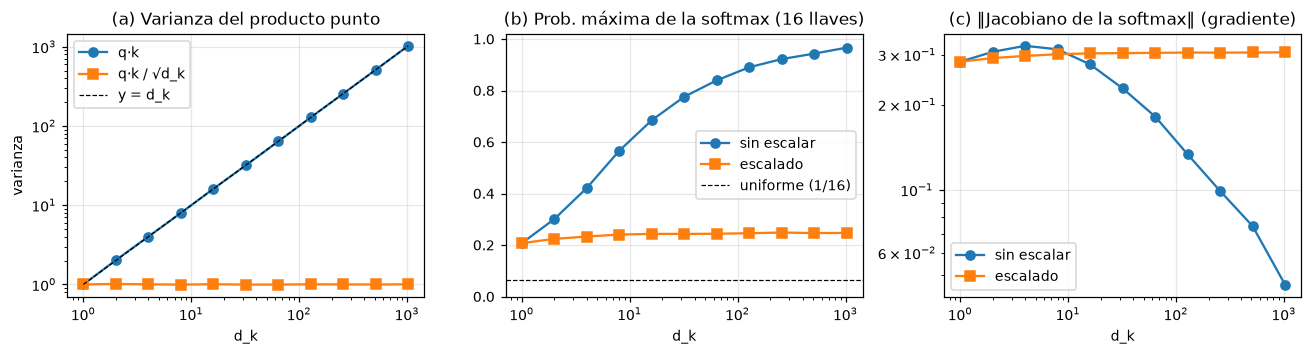

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
ax[0].loglog(escala_df.d_k, escala_df.var_sin_escala, 'o-', label='q·k')
ax[0].loglog(escala_df.d_k, escala_df.var_con_escala, 's-', label='q·k / √d_k')
ax[0].loglog(escala_df.d_k, escala_df.d_k, 'k--', lw=0.8, label='y = d_k')
ax[0].set(title='(a) Varianza del producto punto', xlabel='d_k', ylabel='varianza'); ax[0].legend()
ax[1].semilogx(escala_df.d_k, escala_df.pmax_sin, 'o-', label='sin escalar')
ax[1].semilogx(escala_df.d_k, escala_df.pmax_con, 's-', label='escalado')
ax[1].axhline(1 / N_LLAVES, color='k', ls='--', lw=0.8, label='uniforme (1/16)')
ax[1].set(title='(b) Prob. máxima de la softmax (16 llaves)', xlabel='d_k', ylim=(0, 1.02)); ax[1].legend()
ax[2].loglog(escala_df.d_k, escala_df.normaJ_sin, 'o-', label='sin escalar')
ax[2].loglog(escala_df.d_k, escala_df.normaJ_con, 's-', label='escalado')
ax[2].set(title='(c) ‖Jacobiano de la softmax‖ (gradiente)', xlabel='d_k'); ax[2].legend()
fig.tight_layout(); guardar(fig, 'escalamiento.png'); plt.show()

La varianza de q·k sigue exactamente la recta y = d_k y al escalar se queda en 1. Sin escalar, con d_k = 64 la
softmax ya pone ~84 % de la masa en una sola llave (97 % con d_k = 1024) y la norma del Jacobiano cae de 0.30 a 0.18
(0.05 con d_k = 1024): los gradientes hacia Q y K se vuelven cada vez más pequeños. Con escalamiento ambas curvas quedan planas.

**Costo computacional.** Se mide el tiempo de la atención (batch 1, 8 cabezas, d_k = 64) para n de 128 a 8192 con la
implementación «ingenua» (materializa la matriz n × n) y con `F.scaled_dot_product_attention`, y la memoria de la
matriz de atención que hay que guardar (puntajes y probabilidades, float32).

In [7]:
def sincronizar():
    if DEV.type == 'cuda': torch.cuda.synchronize()
    elif DEV.type == 'mps': torch.mps.synchronize()

def cronometrar(fn, reps=10):
    fn(); sincronizar()                         # calentamiento
    t0 = time.perf_counter()
    for _ in range(reps): fn()
    sincronizar()
    return (time.perf_counter() - t0) / reps * 1000   # ms

H_B, D_B = 8, 64
filas = []
for n in [128, 256, 512, 1024, 2048, 4096, 8192]:
    q, k, v = (torch.randn(1, H_B, n, D_B, device=DEV) for _ in range(3))
    with torch.no_grad():
        t_ing = cronometrar(lambda: atencion(q, k, v)[0])
        t_sdpa = cronometrar(lambda: F.scaled_dot_product_attention(q, k, v))
    mem_matriz = 2 * H_B * n * n * 4 / 2**20          # puntajes + probabilidades (MB)
    mem_qkv = 3 * H_B * n * D_B * 4 / 2**20           # Q, K, V (MB), crecen linealmente
    filas.append({'n': n, 'ms_ingenua': t_ing, 'ms_sdpa': t_sdpa, 'MB_matriz_nxn': mem_matriz, 'MB_QKV': mem_qkv})
    del q, k, v
costo_df = pd.DataFrame(filas)
# Pendiente log-log entre n=2048 y n=8192 (≈ 2 si el costo es cuadrático).
sub = costo_df[costo_df.n >= 2048]
for col in ('ms_ingenua', 'ms_sdpa'):
    print(f'pendiente log-log de {col}: {np.polyfit(np.log(sub.n), np.log(sub[col]), 1)[0]:.2f}')
costo_df.to_csv(os.path.join(REPORTS, 'costo.csv'), index=False)
costo_df

pendiente log-log de ms_ingenua: 2.09
pendiente log-log de ms_sdpa: 2.01


,n,ms_ingenua,ms_sdpa,MB_matriz_nxn,MB_QKV
0,128,0.1631,0.0792,1.0,0.75
1,256,0.3612,0.2001,4.0,1.50
2,512,0.9162,0.2571,16.0,3.00
3,1024,1.3319,0.5492,64.0,6.00
4,2048,4.0748,2.0627,256.0,12.00
5,4096,16.7380,8.3885,1024.0,24.00
6,8192,74.3006,33.4884,4096.0,48.00


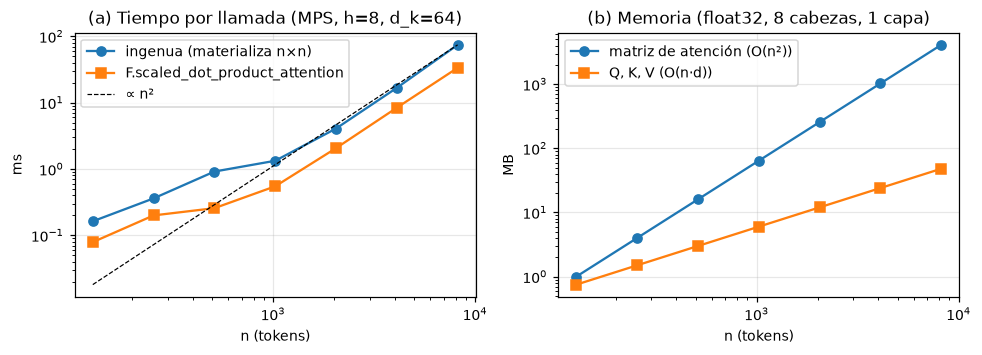

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
ax[0].loglog(costo_df.n, costo_df.ms_ingenua, 'o-', label='ingenua (materializa n×n)')
ax[0].loglog(costo_df.n, costo_df.ms_sdpa, 's-', label='F.scaled_dot_product_attention')
ref = costo_df.ms_ingenua.iloc[-1] * (costo_df.n / costo_df.n.iloc[-1]) ** 2
ax[0].loglog(costo_df.n, ref, 'k--', lw=0.8, label='∝ n²')
ax[0].set(title=f'(a) Tiempo por llamada ({DEV.type.upper()}, h=8, d_k=64)', xlabel='n (tokens)', ylabel='ms'); ax[0].legend()
ax[1].loglog(costo_df.n, costo_df.MB_matriz_nxn, 'o-', label='matriz de atención (O(n²))')
ax[1].loglog(costo_df.n, costo_df.MB_QKV, 's-', label='Q, K, V (O(n·d))')
ax[1].set(title='(b) Memoria (float32, 8 cabezas, 1 capa)', xlabel='n (tokens)', ylabel='MB'); ax[1].legend()
fig.tight_layout(); guardar(fig, 'costo.png'); plt.show()

Entre n = 2048 y 8192 el tiempo crece con pendiente log-log ≈ 2.1 (ingenua) y ≈ 2.0 (`F.sdpa`): duplicar la
longitud cuadruplica el costo (n = 8192 tarda ~75 ms frente a ~4 ms con n = 2048). Para n pequeño domina el costo
fijo de lanzar los kernels y la curva es más plana. El kernel fusionado es ~2× más rápido pero sigue siendo
cuadrático: optimiza el acceso a memoria, no la cantidad de operaciones. En memoria, la matriz de atención de **una
sola capa** con 8 cabezas ya ocupa 4 GB con n = 8192 (frente a 48 MB de Q, K y V); por eso materializarla es lo
primero que limita la longitud de contexto y es lo que evita FlashAttention.

## 6. Verificaciones

### 6.1 La implementación propia contra PyTorch

Se comprueba numéricamente que lo implementado en 5.1–5.2 coincide con las funciones de la sección 4 y que las
máscaras se comportan como dice la documentación:

1. `atencion` vs. `F.scaled_dot_product_attention` (sin máscara, causal y con máscara booleana de padding).
2. `MultiHeadPropia` vs. `nn.MultiheadAttention` copiando los pesos (salida y pesos por cabeza / promediados),
   incluyendo `key_padding_mask` y la máscara causal con la **convención invertida** (True = prohibido).
3. `generate_square_subsequent_mask`: forma y valores, y que un `TransformerEncoder` con esa máscara es causal
   (cambiar un token futuro no altera las salidas anteriores).
4. Propiedades: filas de la softmax suman 1, la self-attention sin posiciones es equivariante a permutaciones, y
   Post-LN / Pre-LN tienen los mismos parámetros.

In [9]:
fijar_semilla()
verif = []
def registrar(nombre, a, b, tol=1e-5):
    err = (a - b).abs().max().item()
    verif.append({'verificación': nombre, 'error máx.': err, 'ok': err < tol})

# 1. atencion propia vs F.scaled_dot_product_attention
q, k, v = (torch.randn(2, 4, 7, 16) for _ in range(3))
registrar('atención vs F.sdpa (sin máscara)', atencion(q, k, v)[0], F.scaled_dot_product_attention(q, k, v))
registrar('atención vs F.sdpa (is_causal=True)', atencion(q, k, v, causal=True)[0],
          F.scaled_dot_product_attention(q, k, v, is_causal=True))
pad = torch.ones(2, 1, 1, 7, dtype=torch.bool); pad[1, ..., 5:] = False      # True = puede atender
registrar('atención vs F.sdpa (attn_mask booleana)', atencion(q, k, v, mascara=pad)[0],
          F.scaled_dot_product_attention(q, k, v, attn_mask=pad))
registrar('atención vs F.sdpa (scale=0.5)', atencion(q, k, v, escala=0.5)[0],
          F.scaled_dot_product_attention(q, k, v, scale=0.5))
registrar('ejercicio a mano vs F.sdpa', salida, F.scaled_dot_product_attention(Q, K, V))

# 2. MultiHeadPropia vs nn.MultiheadAttention con los mismos pesos
d_model, h = 32, 4
ref = nn.MultiheadAttention(d_model, h, batch_first=True).eval()
mia = MultiHeadPropia(d_model, h).eval()
with torch.no_grad():
    Wq, Wk, Wv = ref.in_proj_weight.chunk(3); bq, bk, bv = ref.in_proj_bias.chunk(3)
    for lin, W, b in ((mia.W_q, Wq, bq), (mia.W_k, Wk, bk), (mia.W_v, Wv, bv)):
        lin.weight.copy_(W); lin.bias.copy_(b)
    mia.W_o.weight.copy_(ref.out_proj.weight); mia.W_o.bias.copy_(ref.out_proj.bias)
x = torch.randn(2, 6, d_model)
with torch.no_grad():
    y_ref, p_ref = ref(x, x, x, need_weights=True, average_attn_weights=False)
    y_mia, p_mia = mia(x)
    registrar('MHA propia vs nn.MultiheadAttention (salida)', y_mia, y_ref)
    registrar('MHA propia vs nn.MHA (pesos por cabeza)', p_mia, p_ref)
    _, p_prom = ref(x, x, x, average_attn_weights=True)
    registrar('average_attn_weights=True = promedio de cabezas', p_mia.mean(1), p_prom)
    kpm = torch.zeros(2, 6, dtype=torch.bool); kpm[0, 4:] = True              # True = padding (se ignora)
    y_ref, p_ref = ref(x, x, x, key_padding_mask=kpm, average_attn_weights=False)
    y_mia, p_mia = mia(x, mascara=~kpm[:, None, None, :])                    # convención invertida
    registrar('key_padding_mask (True = ignorar)', y_mia, y_ref)
    registrar('peso sobre posiciones de padding = 0', p_ref[0, :, :, 4:], torch.zeros_like(p_ref[0, :, :, 4:]))
    causal_bool = torch.triu(torch.ones(6, 6, dtype=torch.bool), 1)          # True = prohibido en nn.MHA
    registrar('attn_mask causal en nn.MHA', mia(x, causal=True)[0], ref(x, x, x, attn_mask=causal_bool)[0])
    # Cross-attention con kdim/vdim distintos: las consultas tienen d_model, las llaves/valores 20 dims.
    cross = nn.MultiheadAttention(d_model, h, kdim=20, vdim=20, batch_first=True)
    yc, pc = cross(x, torch.randn(2, 9, 20), torch.randn(2, 9, 20))
    print('cross-attention: salida', tuple(yc.shape), '| pesos', tuple(pc.shape),
          '| q_proj/k_proj/v_proj:', tuple(cross.q_proj_weight.shape), tuple(cross.k_proj_weight.shape))

# 3. Máscara causal de nn.Transformer y encoder causal
m = nn.Transformer.generate_square_subsequent_mask(5)
print('\ngenerate_square_subsequent_mask(5):\n', m)
capa = nn.TransformerEncoderLayer(d_model, h, dim_feedforward=64, dropout=0.0, batch_first=True)
enc = nn.TransformerEncoder(capa, num_layers=2, enable_nested_tensor=False).eval()
with torch.no_grad():
    x2 = x.clone(); x2[:, -1] += 5.0                                          # se altera solo el último token
    a, b = enc(x, mask=nn.Transformer.generate_square_subsequent_mask(6), is_causal=True), \
           enc(x2, mask=nn.Transformer.generate_square_subsequent_mask(6), is_causal=True)
    registrar('encoder causal: tokens 0..4 no ven el futuro', a[:, :-1], b[:, :-1])
    a_nc, b_nc = enc(x), enc(x2)
    print('sin máscara, cambio en tokens 0..4:', round((a_nc[:, :-1] - b_nc[:, :-1]).abs().max().item(), 4))

# 4. Propiedades
with torch.no_grad():
    _, p = atencion(q, k, v)
    registrar('filas de la softmax suman 1', p.sum(-1), torch.ones_like(p.sum(-1)))
    perm = torch.randperm(6)
    registrar('self-attention equivariante a permutaciones', mia(x[:, perm])[0], mia(x)[0][:, perm])
post = nn.TransformerEncoderLayer(512, 8, norm_first=False); pre = nn.TransformerEncoderLayer(512, 8, norm_first=True)
n_post, n_pre = (sum(t.numel() for t in c.parameters()) for c in (post, pre))
print(f'parámetros Post-LN = {n_post:,} | Pre-LN = {n_pre:,}')

verif_df = pd.DataFrame(verif)
verif_df.to_csv(os.path.join(REPORTS, 'verificaciones.csv'), index=False)
print(f"\n{verif_df.ok.sum()} de {len(verif_df)} verificaciones correctas")
verif_df

cross-attention: salida (2, 6, 32) | pesos (2, 6, 9) | q_proj/k_proj/v_proj: (32, 32) (32, 20)

generate_square_subsequent_mask(5):
 tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])
sin máscara, cambio en tokens 0..4: 1.3811
parámetros Post-LN = 3,152,384 | Pre-LN = 3,152,384

14 de 14 verificaciones correctas


,verificación,error máx.,ok
0,atención vs F.sdpa (sin máscara),4.7684e-07,True
1,atención vs F.sdpa (is_causal=True),3.5763e-07,True
2,atención vs F.sdpa (attn_mask booleana),3.5763e-07,True
3,atención vs F.sdpa (scale=0.5),4.7684e-07,True
4,ejercicio a mano vs F.sdpa,2.3842e-07,True
5,MHA propia vs nn.MultiheadAttention (salida),1.1921e-07,True
6,MHA propia vs nn.MHA (pesos por cabeza),8.9407e-08,True
7,average_attn_weights=True = promedio de cabezas,2.9802e-08,True
8,key_padding_mask (True = ignorar),1.3411e-07,True
9,peso sobre posiciones de padding = 0,0.0000e+00,True
